# 🚀 Day 9 — K-Nearest Neighbors (KNN)


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [30]:
##  Load Dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

df.head()

## Explore Dataset
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (6607, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence        

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [31]:
## Create Target Variable

df["Performance"] = (
    df["Exam_Score"] >= 75
).astype(int)

#Check:
df[["Exam_Score", "Performance"]].head(10)

,Exam_Score,Performance
0,67,0
1,61,0
2,74,0
3,71,0
4,70,0
5,71,0
6,67,0
7,66,0
8,69,0
9,72,0


Meaning:

```text
0 → Low Performance
1 → High Performance

In [32]:
#Select Features
features = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Sleep_Hours",
    "Tutoring_Sessions"
]

X = df[features]

y = df["Performance"]

In [33]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

- Why Feature Scaling?

KNN uses distance to determine which observations are closest to each other.

If one feature has a much larger numerical range than another, it can dominate the distance calculation.

For example:

Attendance      → 60–100
Hours_Studied   → 1–10

Therefore, we scale the features before applying KNN.

In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [35]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

In [36]:
#Train Model
knn.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier()

In [37]:
#Make Predictions
y_pred = knn.predict(
    X_test_scaled
)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [38]:
#Evaluate Model
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9803328290468987
Precision: 0.4
Recall   : 0.08
F1 Score : 0.13333333333333333


In [39]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1297
           1       0.40      0.08      0.13        25

    accuracy                           0.98      1322
   macro avg       0.69      0.54      0.56      1322
weighted avg       0.97      0.98      0.97      1322



[[1294    3]
 [  23    2]]


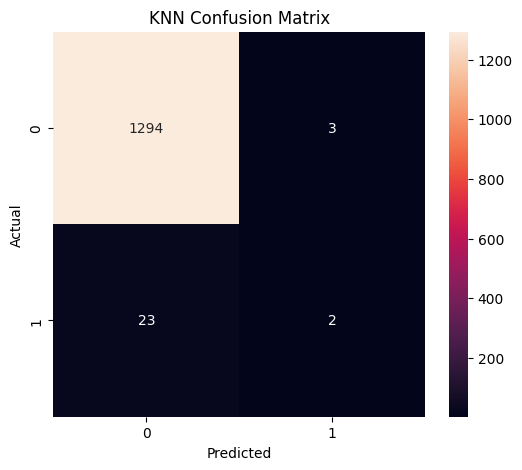

In [40]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
#Test Different K Values : One of the most important parts of KNN is choosing a suitable K.

k_values = range(1, 21)

accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(
        X_train_scaled,
        y_train
    )

    prediction = knn.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    accuracies.append(accuracy)

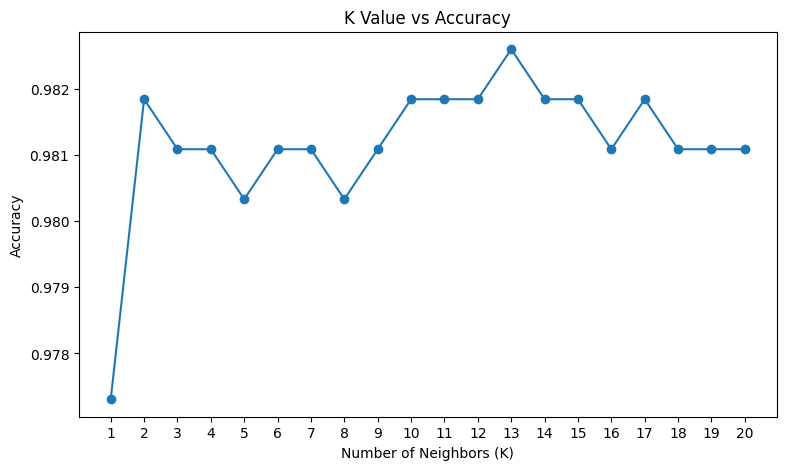

In [42]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")

plt.xticks(list(k_values))

plt.show()

In [43]:
#Find Best K
best_k = k_values[
    accuracies.index(
        max(accuracies)
    )
]

best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 13
Best Accuracy: 0.9826021180030258


# Understanding K
1. Small K

Example:

K = 1

- The model considers only the closest observation.

- This can make the model sensitive to noise and may lead to overfitting.

2. Large K

Example:

K = 50

- The model considers many neighbors.

- This can make the model too general and may lead to underfitting.

> Goal

Find a K that provides a good balance.

In [44]:
# Predict a New Student
new_student = pd.DataFrame({
    "Hours_Studied": [6],
    "Attendance": [90],
    "Previous_Scores": [75],
    "Sleep_Hours": [7],
    "Tutoring_Sessions": [2]
})

# Scale it:

new_student_scaled = scaler.transform(
    new_student
)

# Create the final model using the selected K:

best_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

best_knn.fit(
    X_train_scaled,
    y_train
)

#Predict:

prediction = best_knn.predict(
    new_student_scaled
)

if prediction[0] == 1:
    print("Predicted Performance: High")
else:
    print("Predicted Performance: Low")

Predicted Performance: Low


## 🧠 Key Learning

K-Nearest Neighbors is a simple classification algorithm
that predicts a class based on the nearest observations.

Important concepts learned:

- KNN
- Distance-based classification
- Feature Scaling
- StandardScaler
- Choosing K
- Overfitting
- Underfitting
- Classification Metrics
- Confusion Matrix


🔥 Series progression
- Day 6 → ML Workflow
       
- Day 7 → Linear Regression
       
- Day 8 → Logistic Regression
       
- Day 9 → KNN
       
- Day 10 → Decision Tree